<a href="https://colab.research.google.com/github/archakrishnan7/Supervised-Learning-case-study/blob/main/Supervised_Learning_case_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 A machine learning model to predict customer churn
for a telecommunications company.

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [79]:
data = pd.read_csv('/content/Training_data.csv')
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.4,No
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790,No
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,NaN,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.6,No


1&2 EDA & Data Preprocessing.

In [80]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   gender            5465 non-null   object 
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   object 
 4   Dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   object 
 7   MultipleLines     5634 non-null   object 
 8   InternetService   5634 non-null   object 
 9   OnlineSecurity    5465 non-null   object 
 10  OnlineBackup      5634 non-null   object 
 11  DeviceProtection  5634 non-null   object 
 12  TechSupport       5634 non-null   object 
 13  StreamingTV       5634 non-null   object 
 14  StreamingMovies   5634 non-null   object 
 15  Contract          5634 non-null   object 
 16  PaperlessBilling  5634 non-null   object 


In [81]:
data.shape

(5634, 21)

In [82]:
data.isnull().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


<Axes: xlabel='MonthlyCharges', ylabel='Count'>

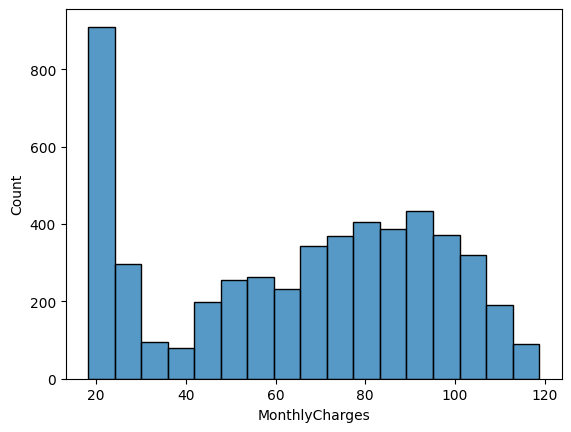

In [83]:
sns.histplot(data=data,x='MonthlyCharges')

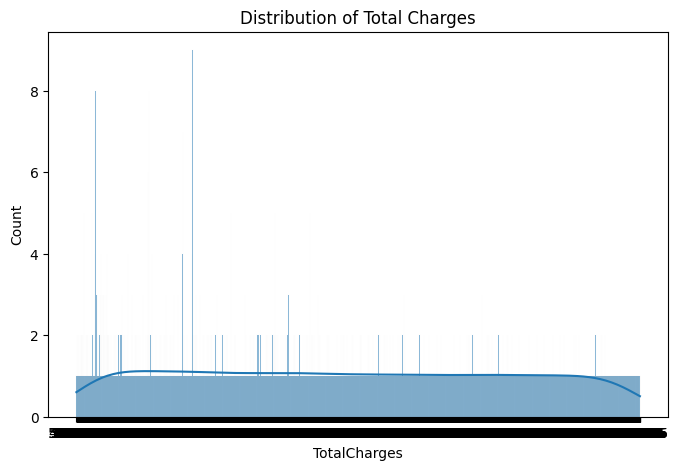

In [84]:
plt.figure(figsize=(8,5))
sns.histplot(data['TotalCharges'],
             bins=30,kde=True)
plt.title('Distribution of Total Charges')
plt.show()


In [85]:
data['gender'] = data['gender'].fillna(data['gender'].mode()[0])
data['OnlineSecurity'] = data['OnlineSecurity'].fillna(data['OnlineSecurity'].mode()[0])
data['MonthlyCharges'] = data['MonthlyCharges'].fillna(data['MonthlyCharges'].median())
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data['TotalCharges'] = data['TotalCharges'].fillna(data['TotalCharges'].median())

In [86]:
data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [87]:
data.duplicated().sum()

np.int64(0)

In [88]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   gender            5634 non-null   object 
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   object 
 4   Dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   object 
 7   MultipleLines     5634 non-null   object 
 8   InternetService   5634 non-null   object 
 9   OnlineSecurity    5634 non-null   object 
 10  OnlineBackup      5634 non-null   object 
 11  DeviceProtection  5634 non-null   object 
 12  TechSupport       5634 non-null   object 
 13  StreamingTV       5634 non-null   object 
 14  StreamingMovies   5634 non-null   object 
 15  Contract          5634 non-null   object 
 16  PaperlessBilling  5634 non-null   object 


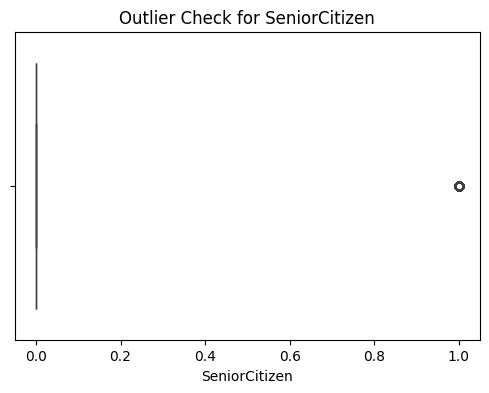

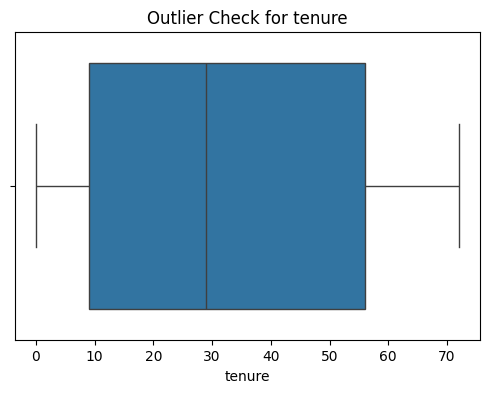

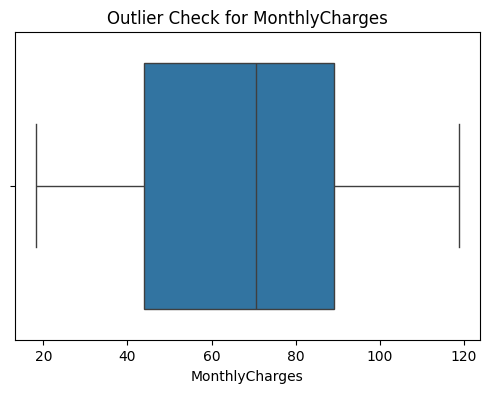

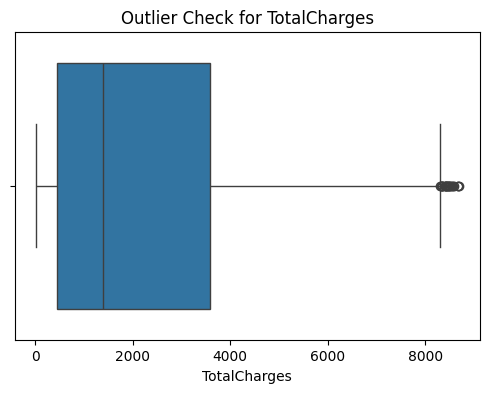

In [89]:
# Outliers
numeric_col = ['SeniorCitizen','tenure','MonthlyCharges','TotalCharges']
for col in numeric_col:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=data[col])
    plt.title(f'Outlier Check for {col}')
    plt.show()

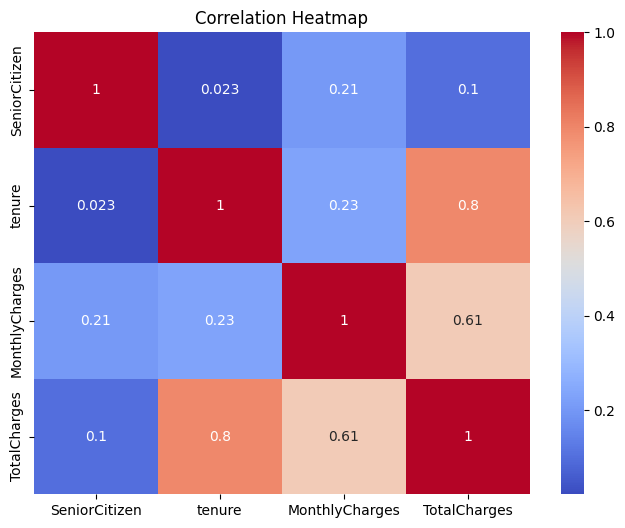

In [90]:
corr = data.corr(numeric_only = True)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

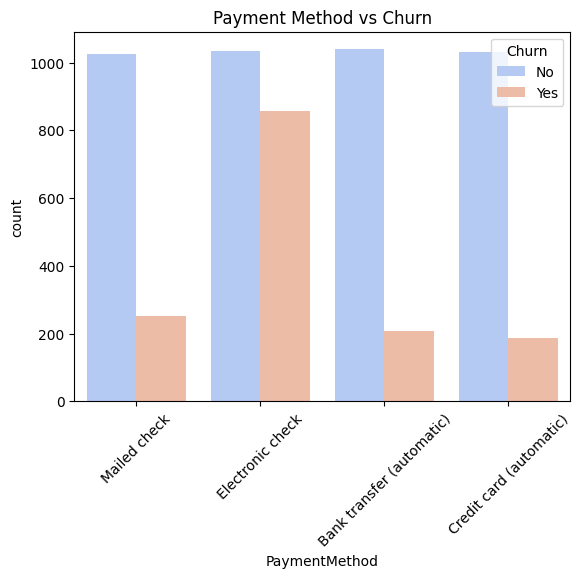

In [91]:
sns.countplot(x='PaymentMethod', hue='Churn', data=data, palette='coolwarm')
plt.xticks(rotation=45)
plt.title('Payment Method vs Churn')
plt.show()


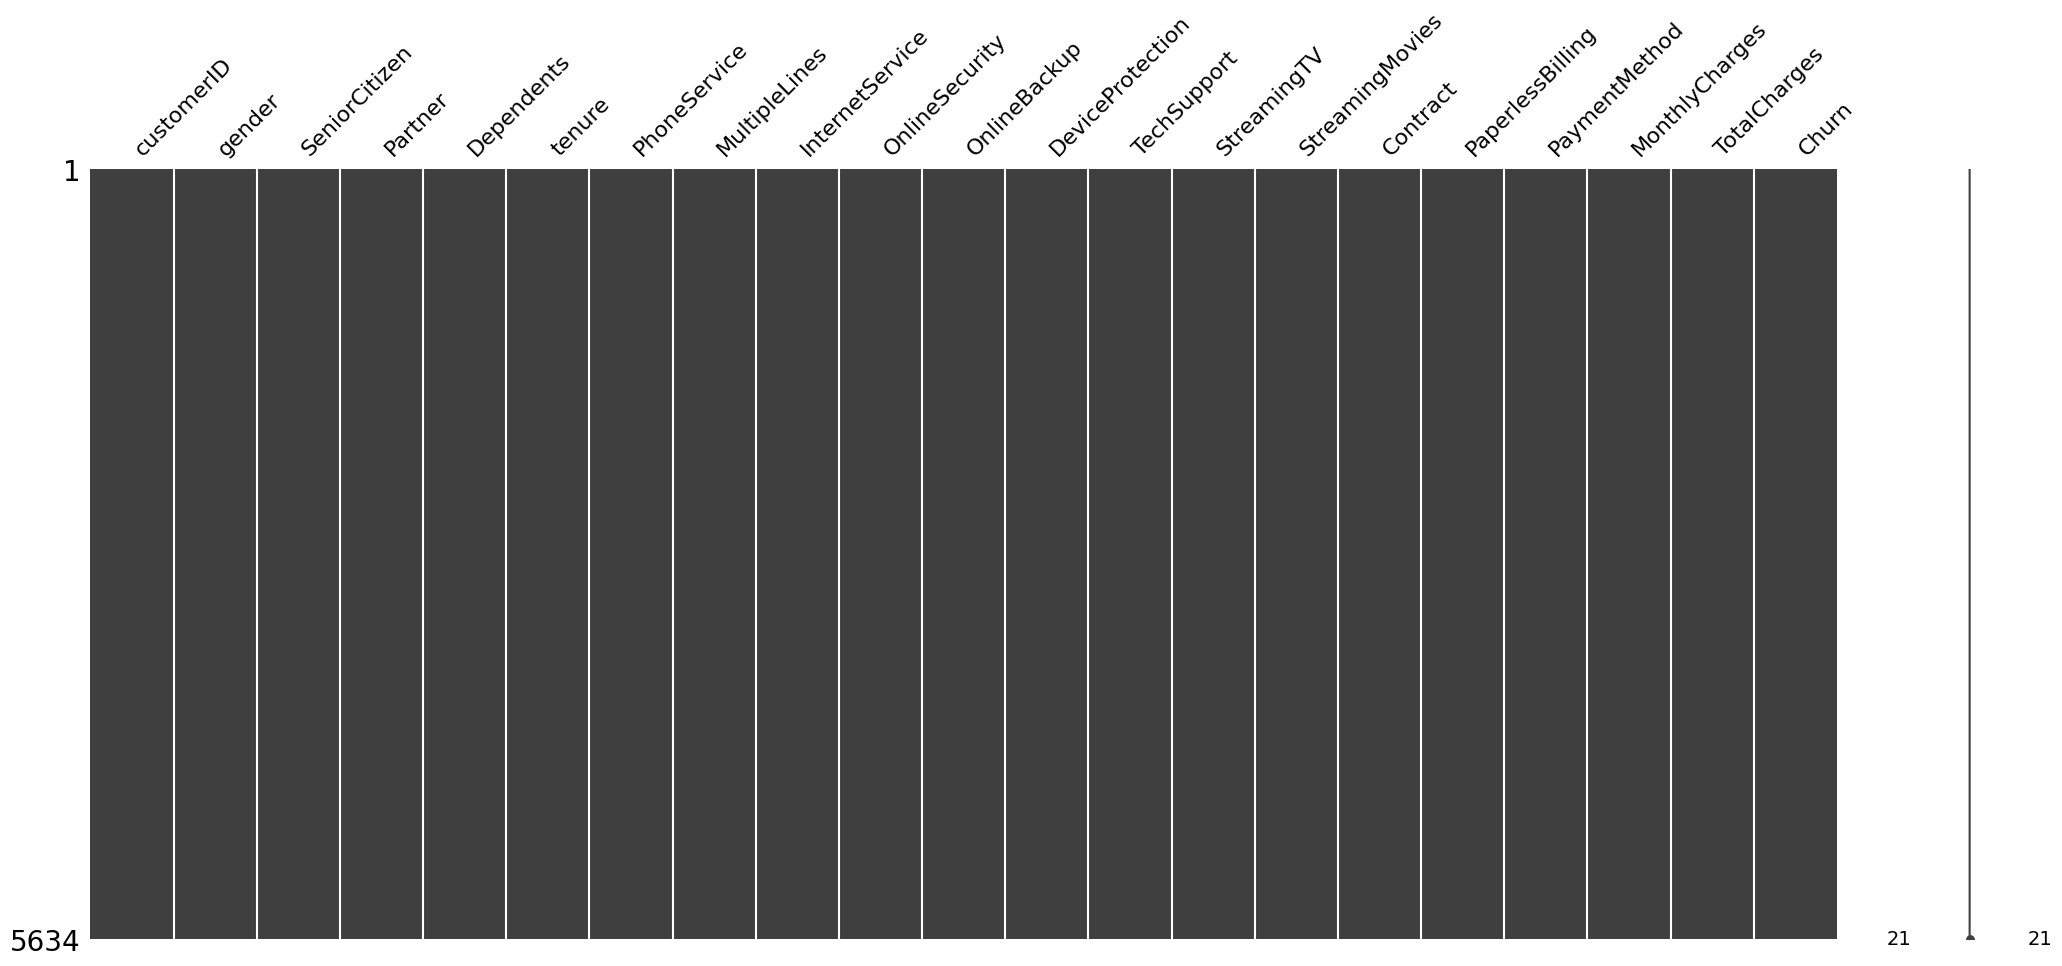

In [92]:
import missingno as msno
msno.matrix(data)
plt.show()

In [93]:
data['customerID'].unique()

array(['9509-MPYOD', '7746-AWNQW', '2208-UGTGR', ..., '4277-BWBML',
       '9110-HSGTV', '3402-XRIUO'], dtype=object)

In [94]:
# The customer ID column contains unique identifiers for each customer so dropping the customerID column.
data = data.drop('customerID', axis=1)


In [95]:
from sklearn.preprocessing import LabelEncoder
label_enc = LabelEncoder()
data['gender'] = label_enc.fit_transform(data['gender'])
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,No,No,35,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,0,0,No,No,28,No,No phone service,DSL,No,No,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.40,No
2,1,0,No,No,56,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,1,0,Yes,No,39,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790.00,No
4,0,0,Yes,Yes,43,No,No phone service,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.60,No


In [96]:
label_enc = LabelEncoder()
data['Partner'] = label_enc.fit_transform(data['Partner'])
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,0,No,35,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,0,0,0,No,28,No,No phone service,DSL,No,No,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.40,No
2,1,0,0,No,56,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,1,0,1,No,39,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790.00,No
4,0,0,1,Yes,43,No,No phone service,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.60,No


In [97]:
label_enc = LabelEncoder()
data['Dependents'] = label_enc.fit_transform(data['Dependents'])
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,0,0,35,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,0,0,0,0,28,No,No phone service,DSL,No,No,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.40,No
2,1,0,0,0,56,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,1,0,1,0,39,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790.00,No
4,0,0,1,1,43,No,No phone service,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.60,No


In [98]:
label_enc = LabelEncoder()
data['PhoneService'] = label_enc.fit_transform(data['PhoneService'])
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,0,0,35,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,0,0,0,0,28,0,No phone service,DSL,No,No,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.40,No
2,1,0,0,0,56,1,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,1,0,1,0,39,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790.00,No
4,0,0,1,1,43,0,No phone service,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.60,No


In [99]:
label_enc = LabelEncoder()
data['MultipleLines'] = label_enc.fit_transform(data['MultipleLines'])
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,0,0,35,1,0,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,0,0,0,0,28,0,1,DSL,No,No,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.40,No
2,1,0,0,0,56,1,2,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,1,0,1,0,39,1,0,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790.00,No
4,0,0,1,1,43,0,1,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.60,No


In [100]:
label_enc = LabelEncoder()
data['InternetService'] = label_enc.fit_transform(data['InternetService'])
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,0,0,35,1,0,2,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,0,0,0,0,28,0,1,0,No,No,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.40,No
2,1,0,0,0,56,1,2,1,No,Yes,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,1,0,1,0,39,1,0,2,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790.00,No
4,0,0,1,1,43,0,1,0,No,Yes,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.60,No


In [101]:
data = pd.get_dummies(data,columns=['OnlineSecurity','OnlineBackup'],dtype = int)
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,DeviceProtection,TechSupport,...,PaymentMethod,MonthlyCharges,TotalCharges,Churn,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes
0,0,0,0,0,35,1,0,2,No internet service,No internet service,...,Mailed check,20.75,700.45,No,0,1,0,0,1,0
1,0,0,0,0,28,0,1,0,Yes,Yes,...,Mailed check,35.75,961.40,No,1,0,0,1,0,0
2,1,0,0,0,56,1,2,1,No,No,...,Electronic check,98.60,5581.05,No,1,0,0,0,0,1
3,1,0,1,0,39,1,0,2,No internet service,No internet service,...,Bank transfer (automatic),20.45,790.00,No,0,1,0,0,1,0
4,0,0,1,1,43,0,1,0,No,Yes,...,Bank transfer (automatic),51.25,2151.60,No,1,0,0,0,0,1


In [102]:
data.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges',
       'Churn', 'OnlineSecurity_No', 'OnlineSecurity_No internet service',
       'OnlineSecurity_Yes', 'OnlineBackup_No',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes'],
      dtype='object')

In [103]:
data['Churn'].unique()

array(['No', 'Yes'], dtype=object)

In [104]:
data = pd.get_dummies(data,columns=['DeviceProtection','TechSupport','StreamingMovies','Contract'],dtype = int)
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,StreamingTV,PaperlessBilling,...,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year
0,0,0,0,0,35,1,0,2,No internet service,No,...,0,0,1,0,0,1,0,0,1,0
1,0,0,0,0,28,0,1,0,No,Yes,...,1,0,0,1,1,0,0,1,0,0
2,1,0,0,0,56,1,2,1,Yes,No,...,0,1,0,0,0,0,1,1,0,0
3,1,0,1,0,39,1,0,2,No internet service,Yes,...,0,0,1,0,0,1,0,0,0,1
4,0,0,1,1,43,0,1,0,Yes,Yes,...,0,0,0,1,1,0,0,0,1,0


In [105]:
label_enc = LabelEncoder()
data['PaperlessBilling'] = label_enc.fit_transform(data['PaperlessBilling'])
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,StreamingTV,PaperlessBilling,...,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year
0,0,0,0,0,35,1,0,2,No internet service,0,...,0,0,1,0,0,1,0,0,1,0
1,0,0,0,0,28,0,1,0,No,1,...,1,0,0,1,1,0,0,1,0,0
2,1,0,0,0,56,1,2,1,Yes,0,...,0,1,0,0,0,0,1,1,0,0
3,1,0,1,0,39,1,0,2,No internet service,1,...,0,0,1,0,0,1,0,0,0,1
4,0,0,1,1,43,0,1,0,Yes,1,...,0,0,0,1,1,0,0,0,1,0


In [106]:
data = pd.get_dummies(data,columns=['StreamingTV','PaymentMethod',],dtype = int)
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,PaperlessBilling,MonthlyCharges,...,Contract_Month-to-month,Contract_One year,Contract_Two year,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,0,0,35,1,0,2,0,20.75,...,0,1,0,0,1,0,0,0,0,1
1,0,0,0,0,28,0,1,0,1,35.75,...,1,0,0,1,0,0,0,0,0,1
2,1,0,0,0,56,1,2,1,0,98.60,...,1,0,0,0,0,1,0,0,1,0
3,1,0,1,0,39,1,0,2,1,20.45,...,0,0,1,0,1,0,1,0,0,0
4,0,0,1,1,43,0,1,0,1,51.25,...,0,1,0,0,0,1,1,0,0,0


In [107]:
label_enc = LabelEncoder()
data['Churn'] = label_enc.fit_transform(data['Churn'])
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,PaperlessBilling,MonthlyCharges,...,Contract_Month-to-month,Contract_One year,Contract_Two year,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,0,0,35,1,0,2,0,20.75,...,0,1,0,0,1,0,0,0,0,1
1,0,0,0,0,28,0,1,0,1,35.75,...,1,0,0,1,0,0,0,0,0,1
2,1,0,0,0,56,1,2,1,0,98.60,...,1,0,0,0,0,1,0,0,1,0
3,1,0,1,0,39,1,0,2,1,20.45,...,0,0,1,0,1,0,1,0,0,0
4,0,0,1,1,43,0,1,0,1,51.25,...,0,1,0,0,0,1,1,0,0,0


3. Feature Engineering.

In [108]:
data.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'PaperlessBilling',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'OnlineSecurity_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No', 'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingMovies_No', 'StreamingMovies_No internet service',
       'StreamingMovies_Yes', 'Contract_Month-to-month', 'Contract_One year',
       'Contract_Two year', 'StreamingTV_No',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [109]:
data['Tenure_Month-To-Month'] = data['tenure'] * data['Contract_Month-to-month']
data['Tenure_One Year'] = data['tenure'] * data['Contract_One year']
data['Tenure_Two Year'] = data['tenure'] * data['Contract_Two year']

In [110]:
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,PaperlessBilling,MonthlyCharges,...,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Tenure_Month-To-Month,Tenure_One Year,Tenure_Two Year
0,0,0,0,0,35,1,0,2,0,20.75,...,0,1,0,0,0,0,1,0,35,0
1,0,0,0,0,28,0,1,0,1,35.75,...,1,0,0,0,0,0,1,28,0,0
2,1,0,0,0,56,1,2,1,0,98.60,...,0,0,1,0,0,1,0,56,0,0
3,1,0,1,0,39,1,0,2,1,20.45,...,0,1,0,1,0,0,0,0,0,39
4,0,0,1,1,43,0,1,0,1,51.25,...,0,0,1,1,0,0,0,0,43,0


In [111]:
data['Customer_Lifetime_Value'] = data['tenure'] * data['MonthlyCharges']
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,PaperlessBilling,MonthlyCharges,...,StreamingTV_No internet service,StreamingTV_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Tenure_Month-To-Month,Tenure_One Year,Tenure_Two Year,Customer_Lifetime_Value
0,0,0,0,0,35,1,0,2,0,20.75,...,1,0,0,0,0,1,0,35,0,726.25
1,0,0,0,0,28,0,1,0,1,35.75,...,0,0,0,0,0,1,28,0,0,1001.00
2,1,0,0,0,56,1,2,1,0,98.60,...,0,1,0,0,1,0,56,0,0,5521.60
3,1,0,1,0,39,1,0,2,1,20.45,...,1,0,1,0,0,0,0,0,39,797.55
4,0,0,1,1,43,0,1,0,1,51.25,...,0,1,1,0,0,0,0,43,0,2203.75


4. Model Development.

In [112]:
y = data['Churn']
X = data.drop('Churn', axis=1)

In [113]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [114]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)


feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importances.head(10))


                    Feature  Importance
9            MonthlyCharges    0.119188
39  Customer_Lifetime_Value    0.115206
10             TotalCharges    0.110423
36    Tenure_Month-To-Month    0.096697
4                    tenure    0.089505
26  Contract_Month-to-month    0.050968
11        OnlineSecurity_No    0.032602
20           TechSupport_No    0.027255
7           InternetService    0.021302
0                    gender    0.021235


In [115]:
from sklearn.preprocessing import StandardScaler

In [116]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [117]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=2000, solver='lbfgs')
log_reg.fit(X_train_scaled, y_train)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [118]:
log_reg.fit(X_train_scaled, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
models = {
    "Logistic Regression": (log_reg, X_test_scaled),
    "Decision Tree": (dt, X_test),
    "Random Forest": (rf, X_test)
}

results = []
for name, (model, X_eval) in models.items():
    y_pred = model.predict(X_eval)
    y_prob = model.predict_proba(X_eval)[:,1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision    Recall        F1   ROC-AUC
0  Logistic Regression  0.805679   0.654135  0.578073  0.613757  0.850844
1        Decision Tree  0.726708   0.489362  0.534884  0.511111  0.669435
2        Random Forest  0.795031   0.637795  0.538206  0.583784  0.836457


5. Model Fine-Tuning.

In [119]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]

}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

print("Tuning Random Forest...")
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
print(f"Best RF Parameters: {rf_grid.best_params_}\n")

xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=XGBClassifier(eval_metric='logloss', random_state=42),
    param_grid=xgb_param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

print("Tuning XGBoost...")
xgb_grid.fit(X_train, y_train)
best_xgb = xgb_grid.best_estimator_
print(f"Best XGBoost Parameters: {xgb_grid.best_params_}\n")

Tuning Random Forest...
Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best RF Parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}

Tuning XGBoost...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best XGBoost Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}



In [120]:
tuned_models = {
    'Tuned Random Forest': best_rf,
    'Tuned XGBoost': best_xgb
}

tuned_results = []

for name, model in tuned_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    tuned_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

df_tuned = pd.DataFrame(tuned_results)
print("Model Performance")
display(df_tuned)

Model Performance


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Tuned Random Forest,0.812777,0.675781,0.574751,0.621185,0.850756
1,Tuned XGBoost,0.811003,0.677419,0.558140,0.612022,0.851315


Test Data.

In [121]:
test_data = pd.read_csv('/content/Testing_data.csv')

print("Original test data info:")
display(test_data.head())
print("\nMissing values in test data before processing:")
display(test_data.isnull().sum())

Original test data info:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,6080-TCMYC,Male,0,Yes,Yes,40,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,81.20,3292.3,No
1,7285-KLOTR,Female,0,Yes,No,12,Yes,Yes,DSL,Yes,...,Yes,No,Yes,Yes,One year,No,Electronic check,78.85,876.75,No
2,7486-KSRVI,Male,0,No,No,43,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,One year,Yes,Electronic check,100.00,4211.55,Yes
3,9924-JPRMC,Male,0,No,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,118.20,8547.15,No
4,4439-YRNVD,Female,0,No,No,10,No,No phone service,DSL,No,...,No,Yes,No,No,Month-to-month,No,Electronic check,36.25,374,No



Missing values in test data before processing:


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [122]:

test_data['gender'] = test_data['gender'].fillna(test_data['gender'].mode()[0])
test_data['OnlineSecurity'] = test_data['OnlineSecurity'].fillna(test_data['OnlineSecurity'].mode()[0])
test_data['MonthlyCharges'] = test_data['MonthlyCharges'].fillna(test_data['MonthlyCharges'].median())

test_data['TotalCharges'] = pd.to_numeric(test_data['TotalCharges'], errors='coerce')
test_data['TotalCharges'] = test_data['TotalCharges'].fillna(test_data['TotalCharges'].median())

test_data = test_data.drop('customerID', axis=1)

test_data['gender'] = test_data['gender'].map({'Female': 0, 'Male': 1})
test_data['Partner'] = test_data['Partner'].map({'No': 0, 'Yes': 1})
test_data['Dependents'] = test_data['Dependents'].map({'No': 0, 'Yes': 1})
test_data['PhoneService'] = test_data['PhoneService'].map({'No': 0, 'Yes': 1})
test_data['PaperlessBilling'] = test_data['PaperlessBilling'].map({'No': 0, 'Yes': 1})
test_data['Churn'] = test_data['Churn'].map({'No': 0, 'Yes': 1})

test_data['MultipleLines'] = test_data['MultipleLines'].map({'No': 0, 'No phone service': 1, 'Yes': 2})
test_data['InternetService'] = test_data['InternetService'].map({'DSL': 0, 'Fiber optic': 1, 'No': 2})

test_data = pd.get_dummies(test_data, columns=['OnlineSecurity','OnlineBackup'], dtype=int)
test_data = pd.get_dummies(test_data, columns=['DeviceProtection','TechSupport','StreamingMovies','Contract'], dtype=int)
test_data = pd.get_dummies(test_data, columns=['StreamingTV','PaymentMethod'], dtype=int)

print("\nTest data after preprocessing:")
display(test_data.head())
print("\nMissing values in test data after processing:")
display(test_data.isnull().sum())


Test data after preprocessing:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,PaperlessBilling,MonthlyCharges,...,Contract_Month-to-month,Contract_One year,Contract_Two year,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,1,40,1,2,1,1,81.20,...,1,0,0,1,0,0,0,0,1,0
1,0,0,1,0,12,1,2,0,0,78.85,...,0,1,0,0,0,1,0,0,1,0
2,1,0,0,0,43,1,2,1,1,100.00,...,0,1,0,0,0,1,0,0,1,0
3,1,0,0,0,72,1,2,1,1,118.20,...,0,0,1,0,0,1,0,0,1,0
4,0,0,0,0,10,0,1,0,0,36.25,...,1,0,0,1,0,0,0,0,1,0



Missing values in test data after processing:


,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
PaperlessBilling,0
MonthlyCharges,0


In [123]:
test_data['CLV_Proxy'] = test_data['tenure'] * test_data['MonthlyCharges']
test_data['Tenure*MonthToMonth'] = test_data['tenure'] * test_data['Contract_Month-to-month']
test_data['Tenure*OneYear'] = test_data['tenure'] * test_data['Contract_One year']
test_data['Tenure*TwoYear'] = test_data['tenure'] * test_data['Contract_Two year']

print("Test data after feature engineering:")
display(test_data[['tenure', 'MonthlyCharges', 'CLV_Proxy', 'Tenure*MonthToMonth', 'Tenure*OneYear', 'Tenure*TwoYear']].head())

Test data after feature engineering:


,tenure,MonthlyCharges,CLV_Proxy,Tenure*MonthToMonth,Tenure*OneYear,Tenure*TwoYear
0,40,81.20,3248.0,40,0,0
1,12,78.85,946.2,0,12,0
2,43,100.00,4300.0,0,43,0
3,72,118.20,8510.4,0,0,72
4,10,36.25,362.5,10,0,0


In [124]:
X_test_final = test_data.drop(columns=['Churn'])
y_test_final = test_data['Churn']


X_test_final_aligned = X_test_final.reindex(columns=X.columns, fill_value=0)

print("Columns in X_test_final_aligned:")
display(X_test_final_aligned.columns)
print("\nShape of X_test_final_aligned:", X_test_final_aligned.shape)
print("Shape of y_test_final:", y_test_final.shape)

Columns in X_test_final_aligned:


Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'PaperlessBilling',
       'MonthlyCharges', 'TotalCharges', 'OnlineSecurity_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No', 'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingMovies_No', 'StreamingMovies_No internet service',
       'StreamingMovies_Yes', 'Contract_Month-to-month', 'Contract_One year',
       'Contract_Two year', 'StreamingTV_No',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Tenure_Month-To-Month', 'Tenure


Shape of X_test_final_aligned: (1409, 40)
Shape of y_test_final: (1409,)


In [125]:
tuned_models_test = {
    'Tuned Random Forest': best_rf,
    'Tuned XGBoost': best_xgb
}

tuned_results_test = []

for name, model in tuned_models_test.items():

    y_pred_test = model.predict(X_test_final_aligned)
    y_prob_test = model.predict_proba(X_test_final_aligned)[:, 1]

    tuned_results_test.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test_final, y_pred_test),
        'Precision': precision_score(y_test_final, y_pred_test),
        'Recall': recall_score(y_test_final, y_pred_test),
        'F1-Score': f1_score(y_test_final, y_pred_test),
        'ROC-AUC': roc_auc_score(y_test_final, y_prob_test)
    })

df_tuned_test = pd.DataFrame(tuned_results_test)
print("--- Tuned Model Performance on New Test Data ---")
display(df_tuned_test)

--- Tuned Model Performance on New Test Data ---


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Tuned Random Forest,0.807665,0.725962,0.413699,0.527051,0.828889
1,Tuned XGBoost,0.801987,0.624277,0.591781,0.607595,0.834352


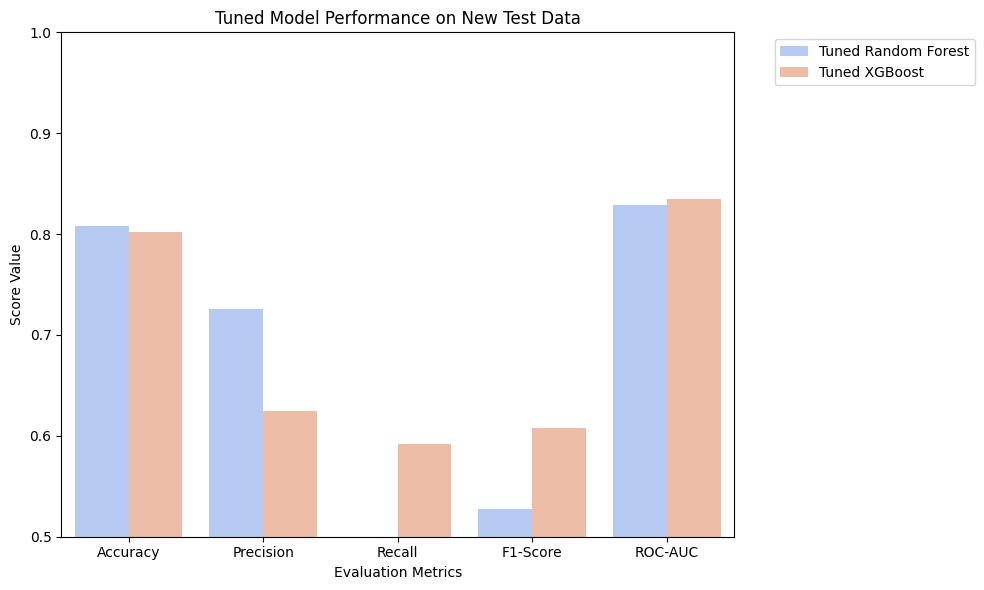

In [126]:
df_melted_tuned_test = df_tuned_test.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted_tuned_test, x='Metric', y='Score', hue='Model', palette='coolwarm')
plt.ylim(0.5, 1.0)
plt.title('Tuned Model Performance on New Test Data')
plt.ylabel('Score Value')
plt.xlabel('Evaluation Metrics')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [127]:
rf_churn_probabilities = best_rf.predict_proba(X_test_final_aligned)[:, 1]

xgb_churn_probabilities = best_xgb.predict_proba(X_test_final_aligned)[:, 1]

predictions_df = pd.DataFrame({
    'RF_Churn_Probability': rf_churn_probabilities,
    'XGB_Churn_Probability': xgb_churn_probabilities
})

print("Churn Probabilities (First 10 customers):")
display(predictions_df.head(10))

Churn Probabilities (First 10 customers):


,RF_Churn_Probability,XGB_Churn_Probability
0,0.459111,0.506745
1,0.179830,0.135678
2,0.259890,0.379753
3,0.175571,0.025943
4,0.255845,0.266138
5,0.344876,0.327140
6,0.175973,0.025024
7,0.170923,0.171175
8,0.193396,0.061065
9,0.020389,0.019533


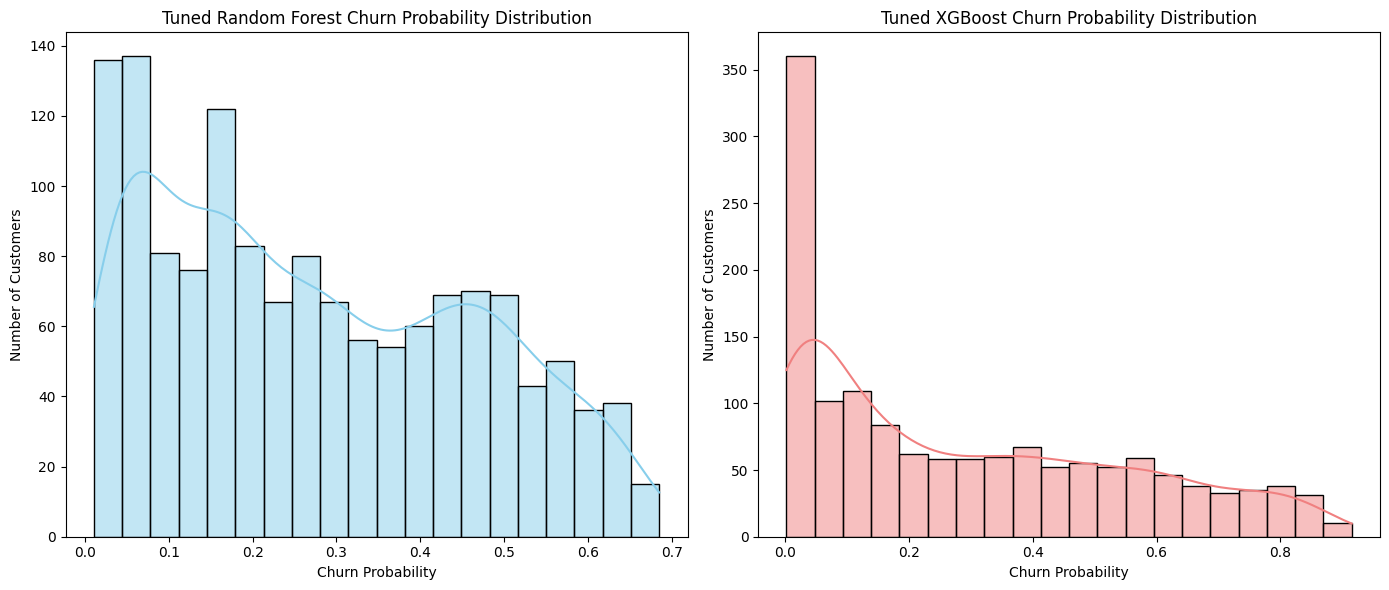


Summary Statistics for Churn Probabilities:


,RF_Churn_Probability,XGB_Churn_Probability
count,1409.000000,1409.000000
mean,0.275143,0.291895
std,0.185946,0.259629
min,0.010537,0.001556
25%,0.111475,0.045631
50%,0.248738,0.221434
75%,0.434141,0.491234
max,0.685140,0.915560


In [128]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(predictions_df['RF_Churn_Probability'], bins=20, kde=True, color='skyblue')
plt.title('Tuned Random Forest Churn Probability Distribution')
plt.xlabel('Churn Probability')
plt.ylabel('Number of Customers')

plt.subplot(1, 2, 2)
sns.histplot(predictions_df['XGB_Churn_Probability'], bins=20, kde=True, color='lightcoral')
plt.title('Tuned XGBoost Churn Probability Distribution')
plt.xlabel('Churn Probability')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

print("\nSummary Statistics for Churn Probabilities:")
display(predictions_df.describe())